### Baseline_Model

In [1]:
import pandas as pd 
import fastf1
fastf1.Cache.enable_cache('f1_cache')
df_2023 = pd.read_csv("datasets/final_merged_2023_data.csv")
df_2023.head(5)

C:\Users\VANSH\AppData\Local\Temp\ipykernel_9092\3849337911.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("datasets/final_merged_2023_data.csv")


,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,LapTime,Sector1Time,Sector2Time,...,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundNumber,Session,Date,GP
0,ALB,23,3,2,MEDIUM,3,0,96.216,30.470,41.812,...,12.0,1017.2,False,41.1,10.0,2.2,1.0,FP1,05-03-2023,Bahrain Grand Prix
1,ALB,23,4,2,MEDIUM,4,0,137.050,42.034,63.859,...,12.0,1017.4,False,41.1,341.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
2,ALB,23,5,2,MEDIUM,5,0,97.024,31.111,41.787,...,13.0,1017.4,False,41.0,342.0,2.5,1.0,FP1,05-03-2023,Bahrain Grand Prix
3,ALB,23,6,2,MEDIUM,6,0,126.270,37.960,52.041,...,13.0,1017.4,False,40.9,342.0,2.0,1.0,FP1,05-03-2023,Bahrain Grand Prix
4,ALB,23,8,3,MEDIUM,8,0,96.859,30.984,41.838,...,13.0,1017.2,False,40.8,344.0,3.5,1.0,FP1,05-03-2023,Bahrain Grand Prix


In [2]:
stints_clean = pd.read_csv('datasets/stints_clean.csv')
stints_clean.head(5)

,GP,Driver,Stint,Compound,StintLength
0,Australian Grand Prix,ALB,1,MEDIUM,6
1,Australian Grand Prix,ALO,1,MEDIUM,8
2,Australian Grand Prix,ALO,2,HARD,46
3,Australian Grand Prix,BOT,1,SOFT,1
4,Australian Grand Prix,BOT,2,HARD,6


In [3]:
model_df = stints_clean[
    (stints_clean['GP'] != 'Qatar Grand Prix') & 
    (stints_clean['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']))
].copy()
model_df.head(5)

,GP,Driver,Stint,Compound,StintLength
0,Australian Grand Prix,ALB,1,MEDIUM,6
1,Australian Grand Prix,ALO,1,MEDIUM,8
2,Australian Grand Prix,ALO,2,HARD,46
3,Australian Grand Prix,BOT,1,SOFT,1
4,Australian Grand Prix,BOT,2,HARD,6


In [4]:
# Checking for NaN values in the target variable
model_df['StintLength'].isna().any()

False

In [16]:
#Defining features and target variable
X = model_df[['GP', 'Compound', 'Stint', 'GP_Stint', 'Compound_Stint']]
y = model_df['StintLength']

model_df['Stint'].value_counts().sort_index()

Stint
1    378
2    337
3    237
4     73
5     24
6      2
7      1
Name: count, dtype: int64

#### Pipeline 

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge

categorial_features = ['GP', 'Compound', 'Stint', 'GP_Stint', 'Compound_Stint']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), categorial_features)
])

model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', Ridge(alpha=1.0))
    
])

In [18]:
model_df['GP_Stint'] = model_df['GP'] + '_S' + model_df['Stint'].astype(str)
model_df['Compound_Stint'] = model_df['Compound'] + '_S' + model_df['Stint'].astype(str)

model_df[['GP', 'Stint', 'GP_Stint']].head()

,GP,Stint,GP_Stint
0,Australian Grand Prix,1,Australian Grand Prix_S1
1,Australian Grand Prix,1,Australian Grand Prix_S1
2,Australian Grand Prix,2,Australian Grand Prix_S2
3,Australian Grand Prix,1,Australian Grand Prix_S1
4,Australian Grand Prix,2,Australian Grand Prix_S2


In [20]:
#splitting into train/test 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)
mae_v2 = mean_absolute_error(y_test, preds)
print('MAE:', mae_v2)

MAE: 5.952710126579771


In [10]:
model.named_steps['preprocess'].get_feature_names_out()

array(['cat__GP_Australian Grand Prix', 'cat__GP_Austrian Grand Prix',
       'cat__GP_Azerbaijan Grand Prix', 'cat__GP_Bahrain Grand Prix',
       'cat__GP_Belgian Grand Prix', 'cat__GP_British Grand Prix',
       'cat__GP_Canadian Grand Prix', 'cat__GP_Dutch Grand Prix',
       'cat__GP_Hungarian Grand Prix', 'cat__GP_Italian Grand Prix',
       'cat__GP_Japanese Grand Prix', 'cat__GP_Las Vegas Grand Prix',
       'cat__GP_Mexico City Grand Prix', 'cat__GP_Miami Grand Prix',
       'cat__GP_Monaco Grand Prix', 'cat__GP_Saudi Arabian Grand Prix',
       'cat__GP_Singapore Grand Prix', 'cat__GP_Spanish Grand Prix',
       'cat__GP_São Paulo Grand Prix', 'cat__GP_United States Grand Prix',
       'cat__Compound_HARD', 'cat__Compound_MEDIUM', 'cat__Compound_SOFT',
       'cat__Stint_1', 'cat__Stint_2', 'cat__Stint_3', 'cat__Stint_4',
       'cat__Stint_5', 'cat__Stint_6', 'cat__Stint_7'], dtype=object)

In [28]:
import numpy as np

feature_names = model.named_steps['preprocess'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefficients
}).sort_values(by='coef', key=abs, ascending=False)

coef_df.head(15)

,feature,coef
14,cat__GP_Monaco Grand Prix,11.357126
13,cat__GP_Miami Grand Prix,7.005080
20,cat__Compound_HARD,6.156888
1,cat__GP_Austrian Grand Prix,-5.824255
3,cat__GP_Bahrain Grand Prix,-5.768837
23,cat__Stint_1,-5.582417
10,cat__GP_Japanese Grand Prix,-5.342618
22,cat__Compound_SOFT,-4.861936
16,cat__GP_Singapore Grand Prix,4.175684
18,cat__GP_São Paulo Grand Prix,-3.895553


In [11]:
results = X_test.copy()
results['Actual Stint Length'] = y_test
results['Predicted Stint Length'] = preds
results['Error'] = abs(results['Actual Stint Length'] - results['Predicted Stint Length'])

results.groupby('GP')['Error'].mean().sort_values(ascending=False)

GP
Monaco Grand Prix           17.611998
Australian Grand Prix       15.658033
Dutch Grand Prix            10.129046
British Grand Prix           9.004604
Azerbaijan Grand Prix        8.702120
Japanese Grand Prix          8.192758
Bahrain Grand Prix           7.448216
Canadian Grand Prix          6.206274
Austrian Grand Prix          5.977583
Saudi Arabian Grand Prix     5.917892
Italian Grand Prix           5.886665
Miami Grand Prix             5.789034
Spanish Grand Prix           5.535650
Mexico City Grand Prix       5.508959
Singapore Grand Prix         5.084578
United States Grand Prix     4.961786
Hungarian Grand Prix         4.722042
Las Vegas Grand Prix         4.161447
Belgian Grand Prix           3.660958
São Paulo Grand Prix         2.982121
Name: Error, dtype: float64

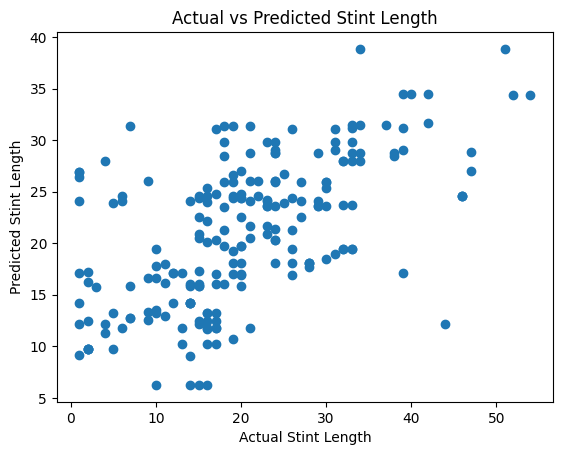

In [12]:
# Visualizing Actual vs Predicted Stint Length
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, preds)

plt.xlabel('Actual Stint Length')
plt.ylabel('Predicted Stint Length')
plt.title('Actual vs Predicted Stint Length')

plt.show()

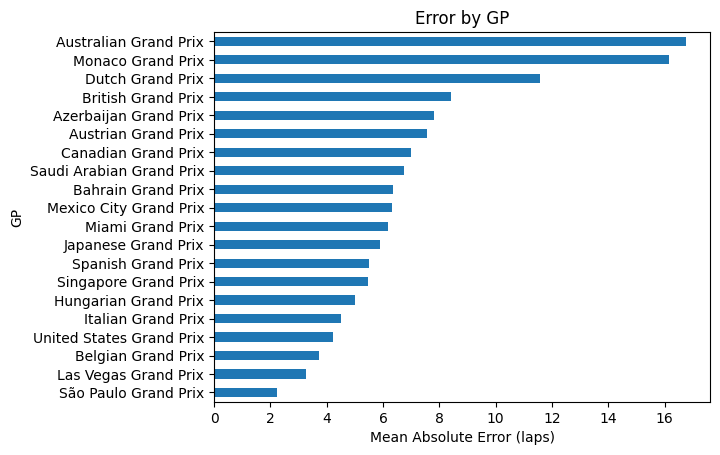

In [14]:
# Visualizing Error by GP
gp_error = results.groupby('GP')['Error'].mean().sort_values()

plt.figure()

gp_error.plot(kind='barh')

plt.xlabel("Mean Absolute Error (laps)")
plt.title("Error by GP")
plt.ylabel("GP")

plt.show()

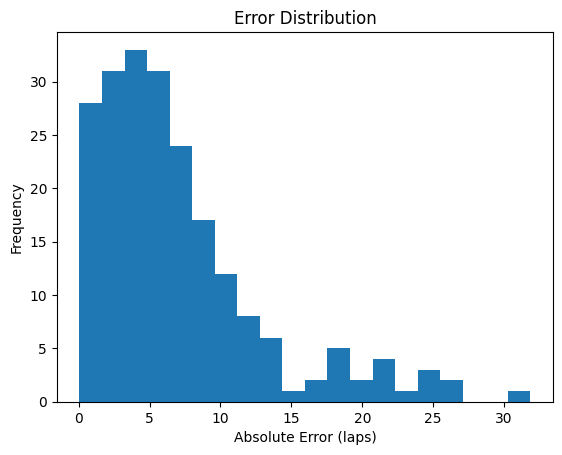

In [13]:
plt.figure()

plt.hist(results['Error'], bins=20)

plt.xlabel("Absolute Error (laps)")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

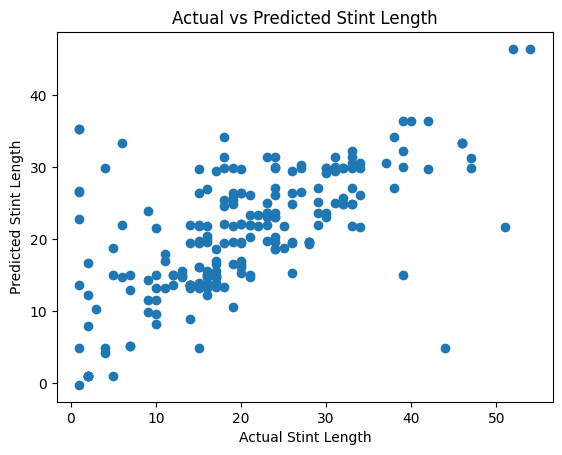

In [22]:
# Visualizing Actual vs Predicted Stint Length
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, preds)

plt.xlabel('Actual Stint Length')
plt.ylabel('Predicted Stint Length')
plt.title('Actual vs Predicted Stint Length')

plt.show()

In [23]:
import numpy as np

feature_names = model.named_steps['preprocess'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefficients
}).sort_values(by='coef', key=abs, ascending=False)

coef_df.head(15)

,feature,coef
85,cat__GP_Stint_Monaco Grand Prix_S1,14.938139
30,cat__GP_Stint_Australian Grand Prix_S1,-11.296412
35,cat__GP_Stint_Austrian Grand Prix_S1,-10.799432
86,cat__GP_Stint_Monaco Grand Prix_S2,-9.930707
53,cat__GP_Stint_British Grand Prix_S1,7.745656
41,cat__GP_Stint_Azerbaijan Grand Prix_S2,7.667099
60,cat__GP_Stint_Dutch Grand Prix_S1,-7.577347
78,cat__GP_Stint_Mexico City Grand Prix_S1,-7.398688
38,cat__GP_Stint_Austrian Grand Prix_S4,6.898165
43,cat__GP_Stint_Bahrain Grand Prix_S1,6.889484


In [24]:
model_df['GP_Stint'].value_counts().min()

1

In [29]:
alphas = [1.0]

In [30]:
from sklearn.metrics import mean_absolute_error
import pandas as pd

results = []

for alpha in alphas:
    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('regressor', Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    

    #coefficient magnitude
    coefs = model.named_steps['regressor'].coef_
    coef_magnitude = abs(coefs).mean()

    results.append({'alpha': alpha, 'MAE': mae, 'avg_coef_magnitude': coef_magnitude})

    results_df = pd.DataFrame(results)
    print(results_df)



   alpha      MAE  avg_coef_magnitude
0    1.0  5.95271            2.777591


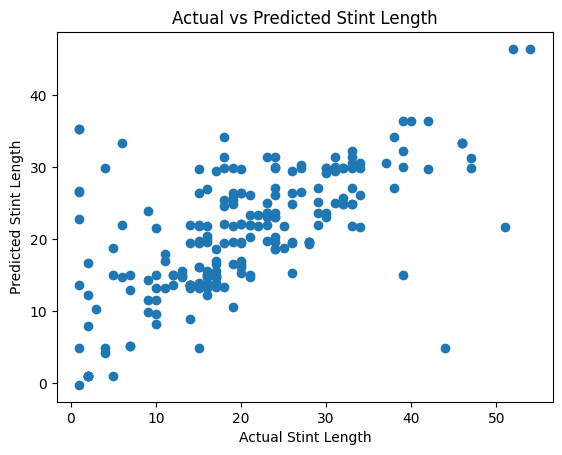

In [31]:
# Visualizing Actual vs Predicted Stint Length
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, preds)

plt.xlabel('Actual Stint Length')
plt.ylabel('Predicted Stint Length')
plt.title('Actual vs Predicted Stint Length')

plt.show()